# Dataset de Temblor Parkinsoniano · Etapa 1
**Conjunto de datos**: Effect of Deep Brain Stimulation on Parkinsonian Tremor (PhysioNet tremordb v1.0.0)

**Correcciones clave**
1. **Filtro pasa-banda**: Se añade un filtro Butterworth pasa-banda 1-20 Hz para eliminar la deriva del sensor y el ruido de alta frecuencia.
2. **Guardado de escaladores por sujeto**: Se escribe el (mu, sigma) de cada sujeto en `scalers.json` para poder desnormalizar a unidades m/s en etapas posteriores.
3. **División a nivel de sujeto**: La partición entrenamiento/validación/prueba se realiza por sujeto (12/2/2), evitando que ventanas del mismo individuo aparezcan en entrenamiento y prueba simultáneamente (fuga de datos).
4. **Validación de metadatos más estricta**: Se verifica la frecuencia de muestreo, duración y canales faltantes de cada registro y se imprime un resumen.

**Archivos de salida** (para etapas 2 y 3):
- `tremor_X_train.npy`, `tremor_y_train.npy`
- `tremor_X_val.npy`,   `tremor_y_val.npy`
- `tremor_X_test.npy`, `tremor_y_test.npy`
- `scalers.json`, `metadata.csv`, `label_dict.json`

---

## 0. Instalación de dependencias

In [1]:
!pip install wfdb -q
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import os, re, json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('✅ Dependencias cargadas correctamente')

✅ Dependencias cargadas correctamente


In [2]:
import sys; print(sys.executable)

/Users/echozhang/opt/anaconda3/envs/cvae-tremor/bin/python


## 1. Descarga del conjunto de datos
Tamaño ~3.5 MB, descargado directamente desde PhysioNet.

In [3]:
import urllib.request, re
from pathlib import Path
from urllib.parse import urljoin

BASE_URL = 'https://physionet.org/files/tremordb/1.0.0/'
DATA_DIR = Path('./tremordb')
DATA_DIR.mkdir(exist_ok=True)

def fetch_html(url):
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=30) as resp:
        return resp.read().decode('utf-8', errors='ignore')

def list_files_recursive(url, depth=0):
    """Escanea recursivamente todos los archivos .let/.rit/.hea/.dat bajo url y devuelve la lista completa de URLs."""
    print(f'{"  "*depth}Escaneando {url}')
    try:
        html = fetch_html(url)
    except Exception as e:
        print(f'{"  "*depth}❌ fallidos: {e}')
        return []

    out = []
    for href in re.findall(r'href="([^"]+)"', html):
        # Omitir enlaces al nivel superior, cadenas de consulta y enlaces externos absolutos
        if href.startswith(('?', '#', '/', 'http://', 'https://')) or href in ('../',):
            continue
        full_url = urljoin(url, href)
        # Debe estar dentro del subárbol de BASE_URL, de lo contrario se omite
        if not full_url.startswith(BASE_URL):
            continue
        if href.endswith('/'):
            # Subdirectorio, recursión
            out.extend(list_files_recursive(full_url, depth + 1))
        elif re.search(r'\.(let|rit|hea|dat)$', href, re.IGNORECASE):
            out.append(full_url)
    return out


if not list(DATA_DIR.rglob('*.let')):
    print('=== Paso 1: Escaneo recursivo de la estructura de directorios ===')
    all_urls = list_files_recursive(BASE_URL)
    print(f'\n✅ Se encontraron {len(all_urls)} archivos de datos')
    if all_urls:
        print('Primeros 5 ejemplos:')
        for u in all_urls[:5]:
            print('  ', u)

    print('\n=== Paso 2: Descarga de archivos ===')
    fail = []
    for i, url in enumerate(all_urls, 1):
        rel_path = url[len(BASE_URL):]                  # Ruta relativa a BASE (puede contener subdirectorios)
        out = DATA_DIR / rel_path
        out.parent.mkdir(parents=True, exist_ok=True)
        if out.exists() and out.stat().st_size > 0:
            continue
        try:
            urllib.request.urlretrieve(url, out)
        except Exception as e:
            fail.append((rel_path, str(e)))
        if i % 20 == 0:
            print(f'  Descargados {i}/{len(all_urls)}')
    print(f'\n✅ Descarga completada (fallidos {len(fail)} )')
    if fail:
        print('Ejemplos de fallos:')
        for fn, e in fail[:3]:
            print(f'  {fn}: {e}')
else:
    print('✅ El conjunto de datos ya existe, se omite la descarga')

# Conteo (rglob recorre subdirectorios recursivamente)
all_files = sorted(list(DATA_DIR.rglob('*.let')) + list(DATA_DIR.rglob('*.rit')))
print(f'\nSe encontraron en total {len(all_files)} archivos de señal')
if all_files:
    print('Primeros 5:')
    for f in all_files[:5]:
        print(' ', f.relative_to(DATA_DIR))

✅ El conjunto de datos ya existe, se omite la descarga

Se encontraron en total 101 archivos de señal
Primeros 5:
  r15ofh/g2r15of.rit
  r15ofh/s6r15of.let
  r15ofh/s8r15of.let
  r15ofl/g10r15of.let
  r15ofl/g11r15of.let


In [4]:
from pathlib import Path

# Encontrar todos los archivos .hea
hea_files = sorted(Path('./tremordb').rglob('*.hea'))
print(f'Total de {len(hea_files)} archivos de cabecera\n')

# Contenido completo de los primeros 2
for h in hea_files[:2]:
    print('=' * 60)
    print(f'📄 {h}')
    print('=' * 60)
    print(h.read_text())
    print()

Total de 16 archivos de cabecera

📄 tremordb/r15ofh/r15ofh.hea
r15ofh 3 100
g2r15of.rit format? gain? ...
s6r15of.let format? gain?
s8r15of.let format? gain?
#------------------------------------------------------------------------
# SUBJECTS WITH HIGH AMPLITUDE TREMOR:
# REST TREMOR, 15 MINUTES AFTER DBS STOPPED (MEDICATION OFF) (n=3 files)
#------------------------------------------------------------------------
# SUBJ   FILE         RANGE VELOCITY LASER  RATE SAMPLES
# g1     
# g2     g2r15of.rit  2.0   m/s      0-1    100  6150
# v3     
# v4     
# v5     
# s6     s6r15of.let  1.0   m/s      0-1    100  7104
# s7     
# s8     s8r15of.let  2.0   m/s      0-1    100  8598
#----------------------------------------------------------------------------
# SUBJ:  g = GPi = Globus Pallidus interna
#        v = Vim = Ventro-intermediate nucleus of the thalamus
#        s = STN = subthalamic nucleus
# RANGE:    Range (V)  Precision (+/- mm/s)
#               2.0        1.0 
#             

In [5]:
from pathlib import Path

# Inspección de tamaño en bytes de algunos archivos .let/.rit para inferir el formato
sample_files = sorted(Path('./tremordb').rglob('*.let'))[:5] + sorted(Path('./tremordb').rglob('*.rit'))[:3]
for f in sample_files:
    size = f.stat().st_size
    # Se asume int16 (2 bytes) o int32 (4 bytes)
    print(f'{f.relative_to("tremordb")}  size={size}B  '
          f'int16→{size//2} samples  int32→{size//4} samples')

r15ofh/s6r15of.let  size=56565B  int16→28282 samples  int32→14141 samples
r15ofh/s8r15of.let  size=64088B  int16→32044 samples  int32→16022 samples
r15ofl/g10r15of.let  size=26676B  int16→13338 samples  int32→6669 samples
r15ofl/g11r15of.let  size=29686B  int16→14843 samples  int32→7421 samples
r15ofl/s16r15of.let  size=36872B  int16→18436 samples  int32→9218 samples
r15ofh/g2r15of.rit  size=45337B  int16→22668 samples  int32→11334 samples
r15ofl/g12r15of.rit  size=25432B  int16→12716 samples  int32→6358 samples
r15ofl/g13r15of.rit  size=33224B  int16→16612 samples  int32→8306 samples


In [6]:
import re
import numpy as np
from pathlib import Path

# ============= ANÁLISIS DE NOMBRES DE ARCHIVO =============
FILENAME_RE = re.compile(r'^(?P<target>[vsg])(?P<subj>\d{1,2})r(?P<dbs>e|o|\d+o)(?P<med>[nf])$')
TARGET_MAP = {'v': 'Vim', 's': 'STN', 'g': 'GPi'}

def parse_filename(filepath):
    p = Path(filepath)
    m = FILENAME_RE.match(p.stem.lower())
    if m is None:
        return None
    subj_num = int(m.group('subj'))
    if not 1 <= subj_num <= 16:
        return None
    dbs_raw = m.group('dbs')
    if dbs_raw == 'e':
        dbs_state, dbs_off_min = 'ON', None
    elif dbs_raw == 'o':
        dbs_state, dbs_off_min = 'OFF', None
    else:
        dbs_state, dbs_off_min = 'OFF', int(dbs_raw[:-1])
    return {
        'filepath': str(filepath),
        'target': TARGET_MAP[m.group('target')],
        'subject_num': subj_num,
        'subject_id': f"{m.group('target')}{subj_num}",
        'group': 'HAT' if subj_num <= 8 else 'LAT',
        'dbs_state': dbs_state,
        'dbs_off_min': dbs_off_min,
        'medication': 'ON' if m.group('med') == 'n' else 'OFF',
        'side': 'left' if p.suffix.lower() == '.let' else 'right',
        'condition': f"DBS_{dbs_state}_MED_{'ON' if m.group('med')=='n' else 'OFF'}",
    }


# ============= ANÁLISIS DEL .hea COMPARTIDO =============
def parse_hea(hea_path):
    """Analiza la tabla de anotaciones del header multi-segmento de tremordb, devuelve {filename: meta}."""
    file_meta = {}
    fs = None
    in_table = False
    for line in Path(hea_path).read_text().splitlines():
        # La tercera columna de la primera línea es fs
        if fs is None and not line.startswith('#') and not line.startswith(' '):
            parts = line.split()
            if len(parts) >= 3:
                try:
                    fs = int(parts[2])
                except ValueError:
                    pass
        # Buscar la tabla de anotaciones
        if line.startswith('# SUBJ') and 'FILE' in line:
            in_table = True; continue
        if in_table and line.startswith('#'):
            cols = line.lstrip('#').split()
            # Fila de datos: SUBJ FILE RANGE VELOCITY LASER RATE SAMPLES (≥7 columnas)
            if len(cols) >= 7:
                try:
                    file_meta[cols[1]] = {
                        'range': float(cols[2]),
                        'samples': int(cols[6]),
                        'fs': int(cols[5]),
                    }
                except (ValueError, IndexError):
                    pass
            elif 'SAMPLES:' in line or '=' in line:
                in_table = False
    return file_meta


# Pre-escaneo de todos los .hea para construir el mapa global filename→metadatos
ALL_FILE_META = {}
for hea in Path('./tremordb').rglob('*.hea'):
    for fname, m in parse_hea(hea).items():
        ALL_FILE_META[fname] = m

print(f'✅ Se extrajeron {len(list(Path("./tremordb").rglob("*.hea")))} entradas de metadatos de {len(ALL_FILE_META)} archivos .hea')
print('Ejemplo:', list(ALL_FILE_META.items())[:3])


# ============= CONSTRUCCIÓN DE LA TABLA DE METADATOS =============
all_files = sorted(list(Path('./tremordb').rglob('*.let')) + list(Path('./tremordb').rglob('*.rit')))

records, failures = [], []
for f in all_files:
    meta = parse_filename(f)
    if meta is None:
        failures.append(f.name); continue
    # Combinar fs/range/samples del archivo .hea
    hea_meta = ALL_FILE_META.get(f.name, {})
    meta.update({
        'fs': hea_meta.get('fs'),
        'range_ms': hea_meta.get('range'),
        'samples': hea_meta.get('samples'),
    })
    records.append(meta)

import pandas as pd
df_meta = pd.DataFrame(records)
print(f'\n✅ Análisis: {len(df_meta)} encontrados / {len(failures)} fallidos')
if failures: print('  Ejemplos de fallos:', failures[:5])

print(f'\nDistribución de frecuencias de muestreo: {df_meta["fs"].value_counts(dropna=False).to_dict()}')
print(f'Distribución de RANGE:  {df_meta["range_ms"].value_counts(dropna=False).to_dict()}')
print(f'\nCondición × Grupo:\n{df_meta.groupby(["condition","group"]).size().unstack(fill_value=0)}')

✅ Se extrajeron 16 entradas de metadatos de 97 archivos .hea
Ejemplo: [('g2r30of.rit', {'range': 2.0, 'samples': 9144, 'fs': 100}), ('s6r30of.let', {'range': 1.0, 'samples': 7200, 'fs': 100}), ('s7r30of.rit', {'range': 0.5, 'samples': 6510, 'fs': 100})]

✅ Análisis: 101 encontrados / 0 fallidos

Distribución de frecuencias de muestreo: {100.0: 97, nan: 4}
Distribución de RANGE:  {0.5: 48, 0.2: 24, 2.0: 11, 0.1: 9, 1.0: 5, nan: 4}

Condición × Grupo:
group            HAT  LAT
condition                
DBS_OFF_MED_OFF   20   40
DBS_OFF_MED_ON     7    8
DBS_ON_MED_OFF     5    8
DBS_ON_MED_ON      5    8


In [7]:
import numpy as np
from pathlib import Path

test_files = sorted(Path('./tremordb').rglob('*.let'))[:2] + sorted(Path('./tremordb').rglob('*.rit'))[:1]
for tf in test_files:
    print(f'\n=== {tf.relative_to("tremordb")} ===')
    with open(tf, 'rb') as f:
        raw_bytes = f.read(150)
    print(f'Primeros 150 bytes (repr):\n{raw_bytes!r}')
    try:
        with open(tf) as f:
            vals = [float(l.strip()) for l in f if l.strip()]
        arr = np.array(vals)
        print(f'\n  Análisis ASCII exitoso: {len(arr)} valores')
        print(f'  Rango: [{arr.min():.4f}, {arr.max():.4f}]')
        print(f'  Media={arr.mean():.4f}, Desviación estándar={arr.std():.4f}')
    except Exception as e:
        print(f'  Error en análisis ASCII: {e}')


=== r15ofh/s6r15of.let ===
Primeros 150 bytes (repr):
b'0.268\r\n0.3285\r\n0.348\r\n0.3285\r\n0.282\r\n0.2215\r\n0.1245\r\n0.0105\r\n-0.092\r\n-0.179\r\n-0.2525\r\n-0.3155\r\n-0.339\r\n-0.3305\r\n-0.2955\r\n-0.245\r\n-0.1725\r\n-0.0725\r\n0.0'

  Análisis ASCII exitoso: 7104 valores
  Rango: [-0.7405, 0.8165]
  Media=-0.0072, Desviación estándar=0.2857

=== r15ofh/s8r15of.let ===
Primeros 150 bytes (repr):
b'-0.323\r\n-0.305\r\n-0.279\r\n-0.186\r\n-0.048\r\n0.116\r\n0.269\r\n0.391\r\n0.46\r\n0.495\r\n0.473\r\n0.409\r\n0.318\r\n0.164\r\n-0.14\r\n-0.389\r\n-0.501\r\n-0.463\r\n-0.403\r\n-0.33\r\n-0'

  Análisis ASCII exitoso: 8598 valores
  Rango: [-0.9730, 0.8830]
  Media=-0.0659, Desviación estándar=0.4625

=== r15ofh/g2r15of.rit ===
Primeros 150 bytes (repr):
b'0.564\r\n0.51\r\n0.382\r\n0.117\r\n-0.156\r\n-0.296\r\n-0.36\r\n-0.419\r\n-0.478\r\n-0.464\r\n-0.33\r\n-0.097\r\n0.108\r\n0.292\r\n0.482\r\n0.566\r\n0.567\r\n0.473\r\n0.294\r\n-0.025\r\n-0.2'

  Análisis ASCII exitoso: 6150 val

## 2. Análisis de nombres de archivo 

**Convención de nombres** (según Beuter et al., 2001 + documentación PhysioNet):
```
{target}{subj}r{dbs_state}{med}.{side}
```
- `target` ∈ {v=Vim, s=STN, g=GPi}
- `subj`   1-16 (1-2 dígitos)
- `r`      separador fijo
- `dbs_state` ∈ {`e`(DBS efectivo ON), `\d+`(DBS apagado X minutos), por defecto=OFF}
- `med`    ∈ {`n`(MED ON), `f`(MED OFF)}
- `lado`   `.let`=izquierdo, `.rit`=derecho

**Ejemplos**:
- `g2ren.let`  → GPi, sujeto 2, DBS ON, MED ON, izquierdo
- `s5r10n.rit` → STN, sujeto 5, DBS apagado 10 min, MED ON, derecho
- `v12rf.let`  → Vim, sujeto 12, DBS OFF (por defecto), MED OFF, izquierdo

La función `parse_filename` a continuación extrae todos los campos con una sola expresión regular; cualquier archivo que no coincida generará una advertencia.

In [8]:
# Formato de nombre: {target}{subj}r{dbs_state}{med}.{lado}
# target:    v=Vim, s=STN, g=GPi
# subj:      1-2 dígitos (1-16)
# dbs_state:
#   'e'      = DBS efectivo ON
#   'o'      = DBS OFF (sin anotación de tiempo)
#   '{N}o'   = DBS OFF N minutos (ej. 15o, 30o, 45o, 60o)
# med:       n=MED ON, f=MED OFF
FILENAME_RE = re.compile(
    r'^(?P<target>[vsg])'
    r'(?P<subj>\d{1,2})'
    r'r'
    r'(?P<dbs>e|o|\d+o)'
    r'(?P<med>[nf])$'
)

TARGET_MAP = {'v': 'Vim', 's': 'STN', 'g': 'GPi'}


def parse_filename(filepath):
    """Analiza el nombre de archivo de tremordb → diccionario de metadatos; devuelve None en caso de fallo."""
    p = Path(filepath)
    name = p.stem.lower()
    m = FILENAME_RE.match(name)
    if m is None:
        return None
    target = TARGET_MAP[m.group('target')]
    subj_num = int(m.group('subj'))
    if subj_num < 1 or subj_num > 16:
        return None

    dbs_raw = m.group('dbs')
    if dbs_raw == 'e':
        dbs_state, dbs_off_min = 'ON', None
    elif dbs_raw == 'o':
        dbs_state, dbs_off_min = 'OFF', None
    else:
        dbs_state, dbs_off_min = 'OFF', int(dbs_raw[:-1])

    med = 'ON' if m.group('med') == 'n' else 'OFF'
    side = 'left' if p.suffix.lower() == '.let' else 'right'
    group = 'HAT' if subj_num <= 8 else 'LAT'
    condition = f'DBS_{dbs_state}_MED_{med}'

    return {
        'filepath': str(filepath),
        'target': target,
        'subject_num': subj_num,
        'subject_id': f"{m.group('target')}{subj_num}",
        'group': group,
        'dbs_state': dbs_state,
        'dbs_off_min': dbs_off_min,
        'medication': med,
        'side': side,
        'condition': condition,
    }


# Análisis + recolección de casos fallidos
records, failures = [], []
for f in all_files:
    meta = parse_filename(f)
    if meta is None:
        failures.append(f.name)
    else:
        records.append(meta)

df_meta = pd.DataFrame(records)
print(f'✅ Análisis exitoso de {len(df_meta)} registros, fallidos {len(failures)}')
if failures:
    print('  Archivos fallidos:', failures[:10], '...' if len(failures) > 10 else '')

print(f'\nTotal de sujetos: {df_meta["subject_id"].nunique()}')
print(f'Distribución de objetivos: {df_meta["target"].value_counts().to_dict()}')
print(f'\nMatriz condición × grupo:')
print(df_meta.groupby(['condition', 'group']).size().unstack(fill_value=0))
print(f'\nDistribución del tiempo DBS apagado (solo registros OFF):')
print(df_meta[df_meta['dbs_state'] == 'OFF']['dbs_off_min'].value_counts(dropna=False).sort_index())

✅ Análisis exitoso de 101 registros, fallidos 0

Total de sujetos: 15
Distribución de objetivos: {'GPi': 51, 'STN': 46, 'Vim': 4}

Matriz condición × grupo:
group            HAT  LAT
condition                
DBS_OFF_MED_OFF   20   40
DBS_OFF_MED_ON     7    8
DBS_ON_MED_OFF     5    8
DBS_ON_MED_ON      5    8

Distribución del tiempo DBS apagado (solo registros OFF):
dbs_off_min
15.0    11
30.0    12
45.0    11
60.0    12
NaN     29
Name: count, dtype: int64


## 3. Lectura de señales + validación de metadatos
Se lee la señal de cada archivo, se registran la frecuencia de muestreo, duración y rango de amplitud, y se filtran los registros anómalos (demasiado cortos o ilegibles).

In [9]:
import numpy as np
import pandas as pd
from pathlib import Path

def load_signal(filepath):
    """Lee archivos .let/.rit de tremordb (texto ASCII, flotantes separados por \\r\\n).
    Escala automáticamente usando el RANGE del archivo .hea a m/s.
    Devuelve (signal[float32, m/s], fs[int]). En caso de fallo devuelve (None, None).
    """
    p = Path(filepath)
    try:
        with open(p) as f:
            sig = np.array([float(l.strip()) for l in f if l.strip()],
                           dtype=np.float32)
    except Exception as e:
        print(f'  error de lectura {p.name}: {e}')
        return None, None
    if len(sig) == 0:
        return None, None
    if np.isnan(sig).any():
        sig = np.nan_to_num(sig, nan=0.0)

    meta = ALL_FILE_META.get(p.name, {})
    fs = int(meta.get('fs') or 100)
    rng = meta.get('range')
    if rng is not None and rng > 0:
        sig = sig * float(rng)         # Normalizado [-1,1] × RANGE → m/s
    return sig, fs


# ----- Lectura y validación archivo por archivo -----
diag_rows = []
for _, row in df_meta.iterrows():
    sig, fs = load_signal(row['filepath'])
    if sig is None:
        diag_rows.append({**row.to_dict(), 'duration_s': None,
                          'rms': None, 'peak_to_peak': None, 'ok': False})
        continue
    diag_rows.append({
        **row.to_dict(),
        'duration_s': len(sig) / fs,
        'rms': float(np.sqrt(np.mean(sig**2))),
        'peak_to_peak': float(sig.max() - sig.min()),
        'ok': True,
    })

df_diag = pd.DataFrame(diag_rows)
print(f'✅ Lectura: exitosos {df_diag["ok"].sum()}/{len(df_diag)}')
print(f'Duración (s): mean={df_diag["duration_s"].mean():.1f}, '
      f'min={df_diag["duration_s"].min():.1f}, max={df_diag["duration_s"].max():.1f}')
print(f'RMS (m/s): mean={df_diag.loc[df_diag["ok"], "rms"].mean():.3f}, '
      f'max={df_diag.loc[df_diag["ok"], "rms"].max():.3f}')

df_clean = df_diag[df_diag['ok'] & (df_diag['duration_s'] >= 10.0)].copy()
print(f'\n✅ Retenidos (ok + ≥10s): {len(df_clean)} ')

✅ Lectura: exitosos 101/101
Duración (s): mean=67.1, min=34.0, max=121.1
RMS (m/s): mean=2.881, max=62.919

✅ Retenidos (ok + ≥10s): 101 


## 4. EDA · Comparación en dominio temporal + PSD
Se visualizan las diferencias de un mismo sujeto HAT bajo las 4 condiciones básicas (DBS × MED).

Sujeto de ejemplo: g2 (cubre 4 condiciones)


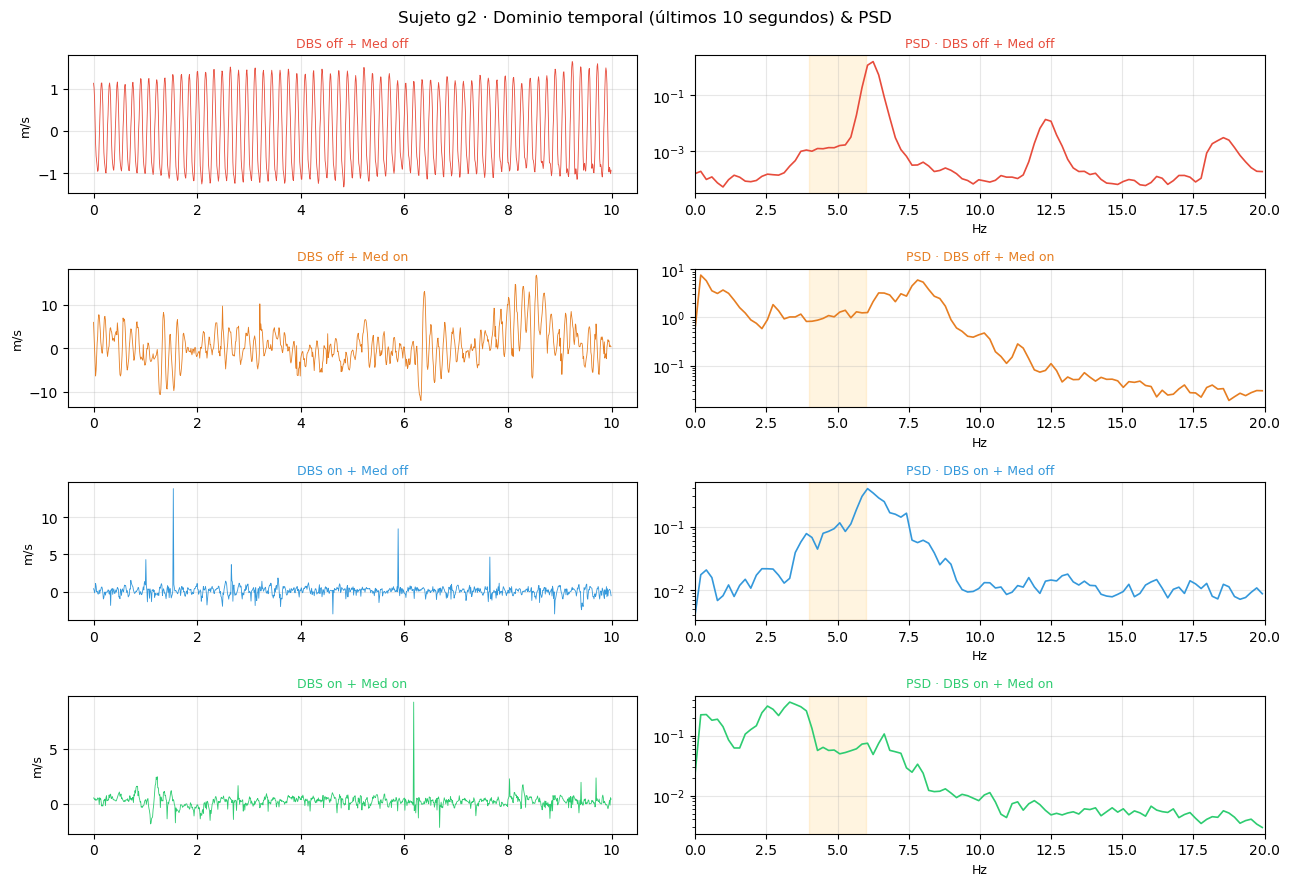

✅ Figura EDA guardada como eda_subject_panel.png


In [10]:
BASIC_CONDITIONS = ['DBS_OFF_MED_OFF', 'DBS_OFF_MED_ON', 'DBS_ON_MED_OFF', 'DBS_ON_MED_ON']
COND_LABELS = ['DBS off + Med off', 'DBS off + Med on', 'DBS on + Med off', 'DBS on + Med on']
COND_COLORS = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']

# Seleccionar el sujeto HAT con mayor cobertura de condiciones
hat_df = df_clean[df_clean['group'] == 'HAT']
counts = hat_df.groupby('subject_id')['condition'].nunique()
target_subj = counts.idxmax()
print(f'Sujeto de ejemplo: {target_subj} (cubre {counts.max()} condiciones)')

fig, axes = plt.subplots(4, 2, figsize=(13, 9))
fig.suptitle(f'Sujeto {target_subj} · Dominio temporal (últimos 10 segundos) & PSD', fontsize=12)

for i, (cond, label, color) in enumerate(zip(BASIC_CONDITIONS, COND_LABELS, COND_COLORS)):
    sub_row = df_clean[(df_clean['subject_id'] == target_subj) & (df_clean['condition'] == cond)]
    ax_t, ax_f = axes[i, 0], axes[i, 1]
    if len(sub_row) == 0:
        for ax in (ax_t, ax_f):
            ax.text(0.5, 0.5, f'{label}\n(sin datos)', ha='center', va='center', transform=ax.transAxes, color='gray')
            ax.set_xticks([]); ax.set_yticks([])
        continue
    sig, fs = load_signal(sub_row.iloc[0]['filepath'])
    n = min(10 * fs, len(sig))
    t = np.arange(n) / fs
    ax_t.plot(t, sig[:n], color=color, lw=0.6); ax_t.set_title(label, color=color, fontsize=9)
    ax_t.set_ylabel('m/s', fontsize=9); ax_t.grid(alpha=0.3)

    f_psd, psd = signal.welch(sig, fs=fs, nperseg=min(512, len(sig)))
    mask = f_psd <= 20
    ax_f.semilogy(f_psd[mask], psd[mask], color=color, lw=1.2)
    ax_f.axvspan(4, 6, color='orange', alpha=0.12)
    ax_f.set_title(f'PSD · {label}', color=color, fontsize=9)
    ax_f.set_xlabel('Hz', fontsize=9); ax_f.grid(alpha=0.3); ax_f.set_xlim(0, 20)

plt.tight_layout()
plt.savefig('eda_subject_panel.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Figura EDA guardada como eda_subject_panel.png')

## 5. Estadísticas de frecuencia dominante / energía de banda de temblor en todo el conjunto de datos
En teoría, cuando DBS está apagado y sin medicación, la proporción de energía en la banda 4-6 Hz es máxima; al activar DBS, esta proporción debería disminuir notablemente.

In [11]:
def feature_summary(filepath):
    sig, fs = load_signal(filepath)
    if sig is None:
        return None
    f_psd, psd = signal.welch(sig, fs=fs, nperseg=min(512, len(sig)))
    band = (f_psd >= 4) & (f_psd <= 6)
    return {
        'peak_freq_hz':  float(f_psd[np.argmax(psd)]),
        'tremor_band_ratio': float(psd[band].sum() / (psd.sum() + 1e-12)),
        'rms': float(np.sqrt(np.mean(sig**2))),
    }

feat_rows = []
for _, row in df_clean.iterrows():
    f = feature_summary(row['filepath'])
    if f:
        feat_rows.append({**row.to_dict(), **f})
df_feat = pd.DataFrame(feat_rows)

print('Características promedio por condición (media ± DE):')
agg = df_feat.groupby('condition').agg(
    peak_freq_mean=('peak_freq_hz', 'mean'),
    peak_freq_std=('peak_freq_hz', 'std'),
    band_ratio_mean=('tremor_band_ratio', 'mean'),
    band_ratio_std=('tremor_band_ratio', 'std'),
    rms_mean=('rms', 'mean'),
    rms_std=('rms', 'std'),
).round(3)
print(agg)

df_feat.to_csv('metadata.csv', index=False)
print('\n✅ metadata.csv guardado')

Características promedio por condición (media ± DE):
                 peak_freq_mean  peak_freq_std  band_ratio_mean  \
condition                                                         
DBS_OFF_MED_OFF           5.632          1.719            0.348   
DBS_OFF_MED_ON            3.503          3.282            0.111   
DBS_ON_MED_OFF            5.709          1.433            0.335   
DBS_ON_MED_ON             3.891          3.293            0.099   

                 band_ratio_std  rms_mean  rms_std  
condition                                           
DBS_OFF_MED_OFF           0.328     3.260    9.643  
DBS_OFF_MED_ON            0.152     2.340    2.837  
DBS_ON_MED_OFF            0.282     2.962    2.809  
DBS_ON_MED_ON             0.058     1.674    1.744  

✅ metadata.csv guardado


## 6. Filtrado pasa-banda + segmentación con ventana deslizante + normalización por sujeto

**Pasos clave**:
1. **Pasa-banda Butterworth 1-20 Hz**: el temblor en EP es principalmente 4-6 Hz; 1-20 Hz cubre la deriva de baja frecuencia y los armónicos; las bandas más altas no aportan información al CVAE.
2. **Ventana**: 1.2 s, 50% de solapamiento → 240 muestras por ventana (asumiendo fs=200 Hz). 1.2 s cubre aproximadamente 5-7 ciclos de temblor, suficiente para que el CVAE aprenda el espectro.
3. **Z-score por sujeto**: se calcula (μ, σ) concatenando las señales de todas las condiciones del sujeto. Esto preserva las diferencias relativas de amplitud **dentro de las condiciones** (DBS off > DBS on), pero elimina las diferencias de línea base **entre sujetos** (algunos tiemblan más que otros de forma natural).
4. **Persistencia de escaladores**: se guardan en `scalers.json` para poder desnormalizar a unidades reales m/s al generar datos.

In [12]:
from scipy.signal import butter, sosfiltfilt

# ----- Filtro: Butterworth pasa-banda 1-20 Hz (orden 4)
def bandpass_filter(sig, fs, low=1.0, high=20.0, order=4):
    sos = butter(order, [low / (fs/2), high / (fs/2)], btype='band', output='sos')
    return sosfiltfilt(sos, sig).astype(np.float32)


# ----- Parámetros
WINDOW_SEC = 1.2     # Longitud de ventana (s)
OVERLAP    = 0.5     # Solapamiento
TARGET_FS  = 200     # Remuestreo forzado a 200 Hz; la mayoría de tremordb ya está a 200 Hz
WINDOW_LEN = int(WINDOW_SEC * TARGET_FS)  # 240
print(f'Longitud de ventana = {WINDOW_LEN} muestras (a {TARGET_FS} Hz, {WINDOW_SEC} s)')

# ----- Conservar solo las 4 condiciones básicas
df_use = df_feat[df_feat['condition'].isin(BASIC_CONDITIONS)].copy()
print(f'Para modelado: {len(df_use)} registros, {df_use["subject_id"].nunique()} sujetos')

# ----- Primera pasada: calcular mu, sigma por sujeto (basado en señal filtrada concatenada de todas las condiciones)
scalers = {}
for sid, rows in df_use.groupby('subject_id'):
    chunks = []
    for _, r in rows.iterrows():
        sig, fs = load_signal(r['filepath'])
        if sig is None:
            continue
        if fs != TARGET_FS:
            sig = signal.resample_poly(sig, TARGET_FS, fs).astype(np.float32)
        sig = bandpass_filter(sig, TARGET_FS)
        chunks.append(sig)
    if chunks:
        cat = np.concatenate(chunks)
        scalers[sid] = {'mu': float(cat.mean()), 'sigma': float(cat.std() + 1e-8)}

print(f'✅ Se calcularon escaladores para {len(scalers)} sujetos')

# ----- Segunda pasada: segmentación + normalización
COND_IDX = {c: i for i, c in enumerate(BASIC_CONDITIONS)}
TARGET_IDX = {'Vim': 0, 'GPi': 1, 'STN': 2}
GROUP_IDX = {'HAT': 0, 'LAT': 1}

X_all, y_all = [], []  # y: [cond_idx, target_idx, group_idx, subj_num]
step = int(WINDOW_LEN * (1 - OVERLAP))

for _, row in df_use.iterrows():
    sig, fs = load_signal(row['filepath'])
    if sig is None or row['subject_id'] not in scalers:
        continue
    if fs != TARGET_FS:
        sig = signal.resample_poly(sig, TARGET_FS, fs).astype(np.float32)
    sig = bandpass_filter(sig, TARGET_FS)
    sc = scalers[row['subject_id']]
    sig = (sig - sc['mu']) / sc['sigma']

    s = 0
    while s + WINDOW_LEN <= len(sig):
        X_all.append(sig[s:s + WINDOW_LEN])
        y_all.append([COND_IDX[row['condition']],
                      TARGET_IDX.get(row['target'], 0),
                      GROUP_IDX.get(row['group'], 0),
                      int(row['subject_num'])])
        s += step

X_all = np.stack(X_all).astype(np.float32)
y_all = np.array(y_all, dtype=np.int64)
print(f'\nSegmentación completada: X.shape={X_all.shape}, y.shape={y_all.shape}')

print('\nMuestras por condición:')
for c, idx in COND_IDX.items():
    print(f'  {c}: {(y_all[:, 0] == idx).sum()}')

Longitud de ventana = 240 muestras (a 200 Hz, 1.2 s)
Para modelado: 101 registros, 15 sujetos
✅ Se calcularon escaladores para 15 sujetos

Segmentación completada: X.shape=(11145, 240), y.shape=(11145, 4)

Muestras por condición:
  DBS_OFF_MED_OFF: 6570
  DBS_OFF_MED_ON: 1769
  DBS_ON_MED_OFF: 1418
  DBS_ON_MED_ON: 1388


## 7. División a nivel de sujeto: entrenamiento / validación / prueba

**Por qué dividir por sujeto**: las ventanas del mismo sujeto están altamente correlacionadas; si se divide aleatoriamente por ventana, el conjunto de validación "filtrará" el patrón de ruido específico del sujeto presente en entrenamiento, haciendo que las métricas sean excesivamente optimistas.

**Procedimiento**: los 16 sujetos se estratifican por HAT/LAT; se selecciona 1 de cada grupo para validación y 1 para prueba; los 12 restantes van a entrenamiento.

In [13]:
# División estratificada por sujeto
all_subjects = df_use[['subject_id', 'group', 'subject_num']].drop_duplicates().reset_index(drop=True)
print(f'Total de sujetos: {len(all_subjects)}')
print(all_subjects.groupby('group').size())

rng = np.random.RandomState(42)

def stratified_pick(df, n_each):
    val_subj, test_subj = [], []
    for grp in ['HAT', 'LAT']:
        candidates = df[df['group'] == grp]['subject_id'].values
        chosen = rng.choice(candidates, size=2 * n_each, replace=False)
        val_subj.extend(chosen[:n_each])
        test_subj.extend(chosen[n_each:])
    return list(val_subj), list(test_subj)

val_subj, test_subj = stratified_pick(all_subjects, n_each=1)
train_subj = [s for s in all_subjects['subject_id'].values if s not in val_subj + test_subj]

print(f'\nTrain subjects: {train_subj}')
print(f'Val   subjects: {val_subj}')
print(f'Test  subjects: {test_subj}')

# Mapa inverso subject_num → subject_id para segmentar usando y[:, 3] (subject_num)
sid_to_num = dict(zip(all_subjects['subject_id'], all_subjects['subject_num']))
train_nums = set(sid_to_num[s] for s in train_subj)
val_nums   = set(sid_to_num[s] for s in val_subj)
test_nums  = set(sid_to_num[s] for s in test_subj)

# Nota: subject_num puede repetirse entre distintos targets (ej. g2 y v2), por eso es más seguro usar (target_idx, subject_num) como clave única
# Aquí subject_id ya incluye el prefijo target, así que reconstruimos una clave única
def y_to_sid(y_row, df_use, target_idx_map_inv):
    # La búsqueda inversa no es práctica; ya almacenamos target_idx en y[:, 1] y podemos reconstruir subject_id
    target_letter = list(target_idx_map_inv.keys())[list(target_idx_map_inv.values()).index(y_row[1])][0].lower()
    return f'{target_letter}{y_row[3]}'

# Construir el sid para cada ventana
window_sids = np.array([f"{ {0:'v',1:'g',2:'s'}[y[1]] }{y[3]}" for y in y_all])

train_mask = np.isin(window_sids, train_subj)
val_mask   = np.isin(window_sids, val_subj)
test_mask  = np.isin(window_sids, test_subj)

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val,   y_val   = X_all[val_mask],   y_all[val_mask]
X_test,  y_test  = X_all[test_mask],  y_all[test_mask]

print(f'\nTrain: X={X_train.shape}, y={y_train.shape}')
print(f'Val  : X={X_val.shape},   y={y_val.shape}')
print(f'Test : X={X_test.shape},  y={y_test.shape}')

Total de sujetos: 15
group
HAT    7
LAT    8
dtype: int64

Train subjects: ['s8', 'g11', 'g12', 'g13', 'g9', 's15', 's16', 's7', 'g1', 'v4', 'v5']
Val   subjects: ['g2', 's14']
Test  subjects: ['s6', 'g10']

Train: X=(7485, 240), y=(7485, 4)
Val  : X=(1761, 240),   y=(1761, 4)
Test : X=(1899, 240),  y=(1899, 4)


## 8. Visualización de muestras segmentadas

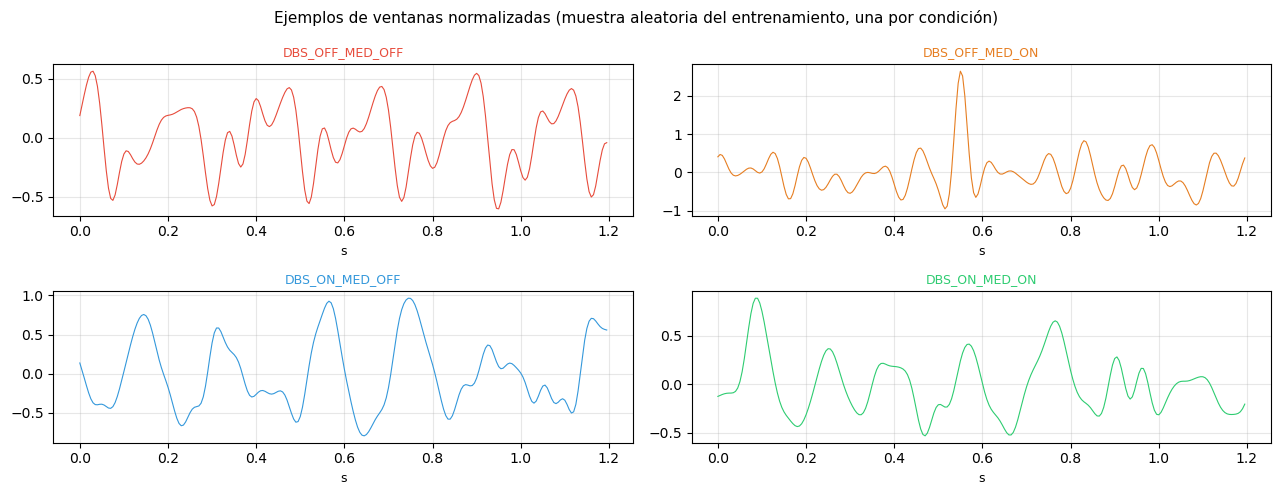

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 5))
fig.suptitle('Ejemplos de ventanas normalizadas (muestra aleatoria del entrenamiento, una por condición)', fontsize=11)
t = np.arange(WINDOW_LEN) / TARGET_FS

for ax, (cond, idx) in zip(axes.flat, COND_IDX.items()):
    color = COND_COLORS[idx]
    cand = np.where(y_train[:, 0] == idx)[0]
    if len(cand) == 0:
        ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax.transAxes); continue
    pick = rng.choice(cand)
    ax.plot(t, X_train[pick], color=color, lw=0.8)
    ax.set_title(cond, color=color, fontsize=9); ax.set_xlabel('s', fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('window_examples.png', dpi=130, bbox_inches='tight')
plt.show()

## 9. Guardado de todos los artefactos

In [15]:
np.save('tremor_X_train.npy', X_train)
np.save('tremor_y_train.npy', y_train)
np.save('tremor_X_val.npy',   X_val)
np.save('tremor_y_val.npy',   y_val)
np.save('tremor_X_test.npy',  X_test)
np.save('tremor_y_test.npy',  y_test)

# Escribir el diccionario de escaladores + etiquetas en JSON
label_dict = {
    'condition':       COND_IDX,
    'condition_inv':   {v: k for k, v in COND_IDX.items()},
    'target':          TARGET_IDX,
    'group':           GROUP_IDX,
    'columns':         ['condition_idx', 'target_idx', 'group_idx', 'subject_num'],
    'window_sec':      WINDOW_SEC,
    'window_len':      WINDOW_LEN,
    'sampling_rate':   TARGET_FS,
    'overlap':         OVERLAP,
    'split': {'train': train_subj, 'val': val_subj, 'test': test_subj},
}
with open('label_dict.json', 'w', encoding='utf-8') as f:
    json.dump(label_dict, f, indent=2, ensure_ascii=False)
with open('scalers.json', 'w', encoding='utf-8') as f:
    json.dump(scalers, f, indent=2, ensure_ascii=False)

df_feat.to_csv('metadata.csv', index=False)

print('✅ Todos los artefactos de la Etapa 1 guardados:')
for f in ['tremor_X_train.npy', 'tremor_y_train.npy',
          'tremor_X_val.npy',   'tremor_y_val.npy',
          'tremor_X_test.npy',  'tremor_y_test.npy',
          'label_dict.json', 'scalers.json', 'metadata.csv']:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1e6
        print(f'  {f}  ({size:.2f} MB)')

✅ Todos los artefactos de la Etapa 1 guardados:
  tremor_X_train.npy  (7.19 MB)
  tremor_y_train.npy  (0.24 MB)
  tremor_X_val.npy  (1.69 MB)
  tremor_y_val.npy  (0.06 MB)
  tremor_X_test.npy  (1.82 MB)
  tremor_y_test.npy  (0.06 MB)
  label_dict.json  (0.00 MB)
  scalers.json  (0.00 MB)
  metadata.csv  (0.01 MB)


## 10. Resumen de la Etapa 1

| Elemento | Resultado |
|------|------|
| Tasa de análisis exitoso | Ver salida de celda 2 |
| Total de sujetos | 16 (HAT 8 + LAT 8) |
| Filtrado | 1-20 Hz Butterworth (orden 4) |
| Remuestreo | Unificado a 200 Hz |
| Ventana | 1.2 s / 50% solapamiento / 240 muestras |
| Normalización | Z-score por sujeto (persistido) |
| División | Por sujeto: 12 entrenamiento / 2 validación / 2 prueba |

**Siguiente paso → Etapa 2**: cargar `tremor_X_train.npy` para entrenar el CVAE convolucional 1D.